In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import nbinom
import random
np.random.seed(42)

In [ ]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. CONFIGURATION
# All simulation parameters are centralized here for easy modification.
# For each value or effect, we define a mean and a standard deviation (std)
# to introduce realistic noise, as requested.
# ==============================================================================

CONFIG = {
    'simulation': {
        'duration_weeks': 12,
    },
    'persona': {
        'age': 35,
        # Base sleep decreases with age. We add noise to the persona's baseline.
        'baseline_sleep_mean': 8.0,
        'baseline_sleep_std': 0.25, # Individual's natural night-to-night variation
        'age_effect_on_sleep': -0.04, # Hours per year over 25
    },
    'confounders': {
        'stress': {
            'weekday_mean': 6.0, 'weekday_std': 1.5,
            'weekend_mean': 3.0, 'weekend_std': 1.0,
        }
    },
    'behaviors': {
        'exercise': {
            'prob_base': 0.5,
            'stress_effect_on_prob_mean': -0.08, # Higher stress -> less likely to exercise
            'stress_effect_on_prob_std': 0.01,
            'duration_mean': 40, 'duration_std': 15,
        },
        'alcohol': {
            'prob_weekday': 0.1, 'prob_weekend': 0.2,
            'stress_effect_on_prob_mean': 0.05, # Higher stress -> more likely to drink
            'stress_effect_on_prob_std': 0.02,
            'units_mean': 2.0, 'units_std': 1.0,
        },
        'late_meal': {
            'prob_base': 0.08,
            'stress_effect_on_prob_mean': 0.04, # Higher stress -> more likely to eat late
            'stress_effect_on_prob_std': 0.02,
            'score_mean': 3.0, 'score_std': 1.5,
        },
    },
    'outcomes': {
        'total_sleep': {
            'exercise_effect_per_30min_mean': 0.20, 'exercise_effect_per_30min_std': 0.05,
            'stress_effect_per_point_mean': -0.05, 'stress_effect_per_point_std': 0.01,
            'late_meal_effect_per_score_point_mean': -0.10, 'late_meal_effect_per_score_point_std': 0.03,
            'alcohol_low_dose_threshold': 2.0,
            'alcohol_effect_per_unit_above_threshold_mean': -0.10, 'alcohol_effect_per_unit_above_threshold_std': 0.04,
            'noise_std': 0.25, # General biological noise for the night
        },
        'rem_sleep': {
            'baseline_percentage_mean': 0.22, 'baseline_percentage_std': 0.03,
            'exercise_effect_per_30min_mean': 0.005, 'exercise_effect_per_30min_std': 0.001,
            'stress_effect_per_point_mean': -0.015, 'stress_effect_per_point_std': 0.003,
            'late_meal_effect_per_score_point_mean': -0.01, 'late_meal_effect_per_score_point_std': 0.002,
            'alcohol_rem_threshold': 2.0, # REM is more sensitive to alcohol
            'alcohol_effect_per_unit_above_threshold_mean': -0.02, 'alcohol_effect_per_unit_above_threshold_std': 0.005,
            'noise_std': 0.05, # Nightly noise in REM percentage
        },
        'biometrics': {
            'rhr': { # Resting Heart Rate
                'base_mean': 60, 'base_std': 4,
                'stress_coeff_mean': 1.0, 'stress_coeff_std': 0.2, # bpm increase per stress point
                'noise_std': 2,
            },
            'hrv': { # Heart Rate Variability
                'base_mean': 80, 'base_std': 10,
                'stress_coeff_mean': -2.0, 'stress_coeff_std': 0.5, # ms decrease per stress point
                'noise_std': 5,
            },
            'skin_temp': {'low': 32.5, 'high': 35.5},
            'breathing_rate': {'mean': 16, 'std': 1.5},
            'blood_oxygen': {'low': 96.0, 'high': 99.5},
        }
    }
}

In [ ]:
# ==============================================================================
# 2. HELPER FUNCTIONS
# Each function has a specific responsibility in the simulation.
# ==============================================================================

def create_persona(config):
    """Creates a persona with calculated baseline attributes."""
    p_config = config['persona']
    persona = {'age': p_config['age']}

    # Calculate baseline sleep with age effect and add noise for the individual's "average"
    age_adjustment = p_config['age_effect_on_sleep'] * max(0, persona['age'] - 25)
    persona['baseline_sleep'] = np.random.normal(p_config['baseline_sleep_mean'], p_config['baseline_sleep_std']) + age_adjustment
    return persona

def generate_daily_stress(day, config):
    """Generates the daily stress level, the primary confounder."""
    s_config = config['confounders']['stress']
    is_weekend = day in ['Sat', 'Sun']

    mean = s_config['weekend_mean'] if is_weekend else s_config['weekday_mean']
    std = s_config['weekend_std'] if is_weekend else s_config['weekday_std']

    stress = np.random.normal(mean, std)
    return np.clip(stress, 0, 10)

def generate_daily_behaviors(stress, day, config):
    """Generates daily behaviors influenced by stress and day of the week."""
    b_config = config['behaviors']
    is_weekend = day in ['Sat', 'Sun']
    behaviors = {}

    # --- Exercise ---
    ex_conf = b_config['exercise']
    stress_effect_on_prob = np.random.normal(ex_conf['stress_effect_on_prob_mean'], ex_conf['stress_effect_on_prob_std'])
    prob_exercise = np.clip(ex_conf['prob_base'] + stress * stress_effect_on_prob, 0, 1)

    if np.random.rand() < prob_exercise:
        behaviors['exercise_minutes'] = max(0, np.random.normal(ex_conf['duration_mean'], ex_conf['duration_std']))
    else:
        behaviors['exercise_minutes'] = 0

    # --- Alcohol ---
    alc_conf = b_config['alcohol']
    stress_effect_on_prob = np.random.normal(alc_conf['stress_effect_on_prob_mean'], alc_conf['stress_effect_on_prob_std'])
    prob_alcohol_base = alc_conf['prob_weekend'] if is_weekend else alc_conf['prob_weekday']
    prob_alcohol = np.clip(prob_alcohol_base + stress * stress_effect_on_prob, 0, 1)

    if np.random.rand() < prob_alcohol:
        behaviors['alcohol_units'] = max(0, np.random.normal(alc_conf['units_mean'], alc_conf['units_std']))
    else:
        behaviors['alcohol_units'] = 0

    # --- Late Meal ---
    lm_conf = b_config['late_meal']
    stress_effect_on_prob = np.random.normal(lm_conf['stress_effect_on_prob_mean'], lm_conf['stress_effect_on_prob_std'])
    prob_late_meal = np.clip(lm_conf['prob_base'] + stress * stress_effect_on_prob, 0, 0.5)

    if np.random.rand() < prob_late_meal:
        behaviors['late_meal_score'] = np.clip(np.random.normal(lm_conf['score_mean'], lm_conf['score_std']), 1, 10)
    else:
        behaviors['late_meal_score'] = 0

    return behaviors

def calculate_sleep_outcomes(persona, behaviors, stress, config):
    """Calculates total sleep and REM sleep based on all factors."""
    ts_conf = config['outcomes']['total_sleep']
    rem_conf = config['outcomes']['rem_sleep']

    # --- Total Sleep Calculation ---
    # Start with persona's baseline sleep
    sleep_hours = persona['baseline_sleep']

    # Add noisy effects from behaviors and stress
    ex_effect = np.random.normal(ts_conf['exercise_effect_per_30min_mean'], ts_conf['exercise_effect_per_30min_std'])
    sleep_hours += (behaviors['exercise_minutes'] / 30) * ex_effect

    stress_effect = np.random.normal(ts_conf['stress_effect_per_point_mean'], ts_conf['stress_effect_per_point_std'])
    sleep_hours += stress * stress_effect

    lm_effect = np.random.normal(ts_conf['late_meal_effect_per_score_point_mean'], ts_conf['late_meal_effect_per_score_point_std'])
    sleep_hours += behaviors['late_meal_score'] * lm_effect

    alc_effect = np.random.normal(ts_conf['alcohol_effect_per_unit_above_threshold_mean'], ts_conf['alcohol_effect_per_unit_above_threshold_std'])
    sleep_hours += max(0, behaviors['alcohol_units'] - ts_conf['alcohol_low_dose_threshold']) * alc_effect

    # Add final biological noise for the night
    sleep_hours += np.random.normal(0, ts_conf['noise_std'])

    # # --- REM Sleep Calculation ---
    # # Start with a noisy baseline percentage
    # rem_percentage = np.random.normal(rem_conf['baseline_percentage_mean'], rem_conf['baseline_percentage_std'])

    # # Add noisy effects from behaviors and stress
    # rem_ex_effect = np.random.normal(rem_conf['exercise_effect_per_30min_mean'], rem_conf['exercise_effect_per_30min_std'])
    # rem_percentage += (behaviors['exercise_minutes'] / 30) * rem_ex_effect

    # rem_stress_effect = np.random.normal(rem_conf['stress_effect_per_point_mean'], rem_conf['stress_effect_per_point_std'])
    # rem_percentage += stress * rem_stress_effect

    # rem_lm_effect = np.random.normal(rem_conf['late_meal_effect_per_score_point_mean'], rem_conf['late_meal_effect_per_score_point_std'])
    # rem_percentage += behaviors['late_meal_score'] * rem_lm_effect

    # rem_alc_effect = np.random.normal(rem_conf['alcohol_effect_per_unit_above_threshold_mean'], rem_conf['alcohol_effect_per_unit_above_threshold_std'])
    # rem_percentage += max(0, behaviors['alcohol_units'] - rem_conf['alcohol_rem_threshold']) * rem_alc_effect

    # # Add final nightly noise for REM percentage
    # rem_percentage += np.random.normal(0, rem_conf['noise_std'])
    # rem_percentage = np.clip(rem_percentage, 0.10, 0.35)

    # rem_hours = sleep_hours * rem_percentage

    return {
        'sleep_time_hours': np.clip(sleep_hours, 3, 12),
        # 'rem_sleep_hours': np.clip(rem_hours, 0, sleep_hours)
    }

def generate_biometrics(stress, config):
    """Generates other physiological metrics."""
    bio_conf = config['outcomes']['biometrics']
    biometrics = {}

    # RHR and HRV are influenced by stress
    rhr_conf = bio_conf['rhr']
    base_rhr = np.random.normal(rhr_conf['base_mean'], rhr_conf['base_std'])
    stress_coeff_rhr = np.random.normal(rhr_conf['stress_coeff_mean'], rhr_conf['stress_coeff_std'])
    biometrics['resting_heart_rate'] = base_rhr + (stress * stress_coeff_rhr) + np.random.normal(0, rhr_conf['noise_std'])

    hrv_conf = bio_conf['hrv']
    base_hrv = np.random.normal(hrv_conf['base_mean'], hrv_conf['base_std'])
    stress_coeff_hrv = np.random.normal(hrv_conf['stress_coeff_mean'], hrv_conf['stress_coeff_std'])
    biometrics['heart_rate_variability'] = base_hrv + (stress * stress_coeff_hrv) + np.random.normal(0, hrv_conf['noise_std'])

    # Other metrics are independent random variables
    biometrics['skin_temperature_c'] = np.random.uniform(bio_conf['skin_temp']['low'], bio_conf['skin_temp']['high'])
    biometrics['breathing_rate'] = np.random.normal(bio_conf['breathing_rate']['mean'], bio_conf['breathing_rate']['std'])
    biometrics['blood_oxygen_spo2'] = np.random.uniform(bio_conf['blood_oxygen']['low'], bio_conf['blood_oxygen']['high'])

    return biometrics

In [ ]:
# ==============================================================================
# 3. MAIN SIMULATION FUNCTION
# This function orchestrates the entire data generation process.
# ==============================================================================

def run_simulation(config):
    """
    Generates a synthetic health log for a specified duration.

    Args:
        config (dict): A dictionary containing all simulation parameters.

    Returns:
        pd.DataFrame: A DataFrame with the complete daily log.
    """
    num_weeks = config['simulation']['duration_weeks']
    print(f"Generating synthetic data for a {num_weeks} week period...")

    persona = create_persona(config)
    daily_logs = []
    days_of_week = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    for _ in range(num_weeks):
        for day in days_of_week:
            # 1. Generate latent confounder (stress)
            daily_stress = generate_daily_stress(day, config)

            # 2. Generate behaviors influenced by confounder
            behaviors = generate_daily_behaviors(daily_stress, day, config)

            # 3. Calculate primary outcomes (sleep)
            sleep_outcomes = calculate_sleep_outcomes(persona, behaviors, daily_stress, config)

            # 4. Generate secondary biometrics
            biometrics = generate_biometrics(daily_stress, config)

            # 5. Consolidate and store the log for the day
            day_log = {
                'day_of_week': day,
                'daily_stress_level': daily_stress,
                **behaviors,
                **sleep_outcomes,
                **biometrics,
            }
            daily_logs.append(day_log)

    # --- Format and return the final DataFrame ---
    df = pd.DataFrame(daily_logs)

    # Apply rounding for readability
    rounding_rules = {
        'daily_stress_level': 1, 'exercise_minutes': 1, 'alcohol_units': 1,
        'late_meal_score': 1, 'sleep_time_hours': 2,
        # 'rem_sleep_hours': 2,
        'resting_heart_rate': 0, 'heart_rate_variability': 1,
        'skin_temperature_c': 2, 'breathing_rate': 0, 'blood_oxygen_spo2': 1
    }
    for col, dec in rounding_rules.items():
        df[col] = df[col].round(dec)

    # Ensure HRV has a realistic floor
    df['heart_rate_variability'] = df['heart_rate_variability'].clip(lower=15)

    return df

In [ ]:
# ==============================================================================
# 4. EXECUTION BLOCK
# ==============================================================================

if __name__ == "__main__":
    synthetic_data = run_simulation(CONFIG)

    print("\n--- Synthetic Health Log (First 10 days) ---")
    print(synthetic_data.head(10))

    print("\n--- Dataframe Info and Description ---")
    synthetic_data.info()
    print("\n")
    print(synthetic_data.describe())

Generating synthetic data for a 12 week period...

--- Synthetic Health Log (First 10 days) ---
  day_of_week  daily_stress_level  exercise_minutes  alcohol_units  \
0         Mon                 5.8               0.0            0.0   
1         Tue                 9.2               0.0            2.7   
2         Wed                 2.9              51.4            2.0   
3         Thu                 5.9               0.0            0.0   
4         Fri                 5.3               0.0            0.0   
5         Sat                 2.0               0.0            0.0   
6         Sun                 3.8               0.0            1.7   
7         Mon                 6.0               0.0            0.9   
8         Tue                 4.2               0.0            1.2   
9         Wed                 6.7               0.0            2.3   

   late_meal_score  sleep_time_hours  resting_heart_rate  \
0              0.0              7.60                75.0   
1            

In [ ]:
synthetic_data

,day_of_week,daily_stress_level,exercise_minutes,alcohol_units,late_meal_score,sleep_time_hours,resting_heart_rate,heart_rate_variability,skin_temperature_c,breathing_rate,blood_oxygen_spo2
0,Mon,5.8,0.0,0.0,0.0,7.60,75.0,55.6,34.31,15.0,99.1
1,Tue,9.2,0.0,2.7,0.0,7.63,71.0,53.6,33.92,16.0,96.7
2,Wed,2.9,51.4,2.0,0.0,7.93,58.0,66.2,35.12,19.0,99.5
3,Thu,5.9,0.0,0.0,0.0,7.47,73.0,49.3,32.86,18.0,96.2
4,Fri,5.3,0.0,0.0,0.0,7.73,61.0,67.6,32.63,16.0,97.2
...,...,...,...,...,...,...,...,...,...,...,...
79,Wed,6.1,0.0,1.8,0.0,7.73,68.0,67.8,34.52,16.0,97.7
80,Thu,5.0,0.0,3.5,0.0,7.73,72.0,78.1,34.30,17.0,97.9
81,Fri,5.9,0.0,0.0,0.0,7.37,63.0,52.6,34.04,12.0,98.9
82,Sat,2.7,22.4,0.0,0.0,7.74,65.0,76.4,34.16,14.0,96.3


**Exercise has positive influence on sleep.**

Reference: "Exercise and Sleep: A Systematic Review of Previous Meta-Analyses"

**Moderate to high dose of alcohol ingestion reduces sleep.**

Reference: "Alcohol and sleep I: effects on normal sleep"

**Stress reduces multiple types of sleep.**

Reference: "The Effect of Psychosocial Stress on Sleep"

In [ ]:
daily_log_string = df.to_string(index=False)

llm_prompt = f"""
Based on the following 7-day daily log, write a comprehensive natural language description of the person's entire week.
For each day, describe the daily activities, and provide a reasonable timestamp for each activity.

7-Day Daily Log:
{daily_log_string}

Start with the morning of Monday and progress chronologically through the week. Example for one day:
"On Monday, the person experienced a moderately high stress level of 6.3. They did not engage in any exercise and consumed about 1.25 units of alcohol later in the day. In the night, they have 7.34 hours of sleep."

Your Log should include variations and noises, from the following aspects:
1. Semantic Variation
Goal: Express the same data point in different ways.
Method: You can use natural, varied language
Example: “Notes: stressful afternoon meeting“, or “Mood: drained“ for stress.

2. Manifestation Noise:
Goal: Deconstruct a single outcome into its constituent parts.
Example: You can use sleep interruptions, hard to fall in sleep, etc to express sleep quality alongside the sleep durations.

3. Omission
Goal: A realistic person's activity recoding should contain gaps. They could be affected by events like travels, sicks.
Method: Introduce random logging gaps.
Example: You may randomly exclude “exercise” and majority of activities.

Please only include the description related to the activities in the provided 7-Day Daily Log. No assumption, no explanation, no comment, just plain, objective expressions for the activities.
Return only the activity log and nothing else.
"""


print("Generating a comprehensive description for the 7-day log...")
response = client.generate(llm_prompt)
full_week_description = response
print("\nFull Week Description:\n")
print(full_week_description)


Generating a comprehensive description for the 7-day log...

Full Week Description:

Content(ContentChunk('**Monday**\n*   **~', mimetype='text/plain', metadata=role: "ASSISTANT"), ContentChunk('7:00 AM:** Woke up after approximately 7.01 hours of sleep from Sunday night. The morning felt adequately rested.\n*   **~9:00 AM - 5:00 PM:** The general mood of', mimetype='text/plain', metadata=role: "ASSISTANT"), ContentChunk(' the day indicated a moderately elevated stress level of 6.2. No physical activity was undertaken throughout the day.\n*   **~6:00 PM - 10:00 PM:** The evening passed quietly. No alcohol was', mimetype='text/plain', metadata=role: "ASSISTANT"), ContentChunk(' consumed.\n\n**Tuesday**\n*   **~6:50 AM:** The sleep duration of 7.03 hours concluded early Tuesday. Despite the average sleep duration, a lingering sense of fatigue was present.\n*   ', mimetype='text/plain', metadata=role: "ASSISTANT"), ContentChunk('**~9:00 AM - 5:30 PM:** The day was characterized by an extr

In [ ]:
response1 = response

In [ ]:
response

\*\*Monday\*\*\
\* ​ ​ ​\*\*~7:00 AM:\*\* Woke up after approximately 7\.01 hours of sleep from Sunday night\. The morning felt adequately rested\.\
\* ​ ​ ​\*\*~9:00 AM \- 5:00 PM:\*\* The general mood of the day indicated a moderately elevated stress level of 6\.2\. No physical activity was undertaken throughout the day\.\
\* ​ ​ ​\*\*~6:00 PM \- 10:00 PM:\*\* The evening passed quietly\. No alcohol was consumed\.\
\
\*\*Tuesday\*\*\
\* ​ ​ ​\*\*~6:50 AM:\*\* The sleep duration of 7\.03 hours concluded early Tuesday\. Despite the average sleep duration, a lingering sense of fatigue was present\.\
\* ​ ​ ​\*\*~9:00 AM \- 5:30 PM:\*\* The day was characterized by an extremely high stress level, peaking at 8\.4, indicating a particularly demanding period\. No exercise activities were logged\.\
\* ​ ​ ​\*\*~8:00 PM:\*\* A small amount of alcohol, approximately 0\.43 units, was consumed\.\
\* ​ ​ ​\*\*~10:45 PM:\*\* Retired for the night, feeling quite drained\.\
\
\*\*Wednesday\*\*\
\* ​ ​ ​\*\*~6:30 AM:\*\* Sleep from Tuesday night extended to 7\.33 hours, providing a slightly more refreshed start to Wednesday morning\.\
\* ​ ​ ​\*\*~9:00 AM \- 5:00 PM:\*\* A high level of mental strain was recorded, with the daily stress reaching 8\.0\. Zero minutes of exercise were performed\.\
\* ​ ​ ​\*\*~7:30 PM:\*\* About 1\.09 units of alcohol were consumed during the evening\.\
\
\*\*Thursday\*\*\
\* ​ ​ ​\*\*~7:00 AM:\*\* After roughly 6\.99 hours of sleep, the morning felt a little sluggish, suggesting some interruptions during the night\.\
\* ​ ​ ​\*\*~9:00 AM \- 5:00 PM:\*\* The daily log showed a consistent high stress level of 7\.0\. No physical exertion was tracked\.\
\* ​ ​ ​\*\*~8:30 PM:\*\* Nearly 1\.79 units of alcohol were consumed\.\
\* ​ ​ ​\*\*~10:45 PM:\*\* Went to bed\.\
\
\*\*Friday\*\*\
\* ​ ​ ​\*\*~7:15 AM:\*\* Woke after a shorter night of 6\.81 hours of sleep, feeling the cumulative effect of the week's demands\.\
\* ​ ​ ​\*\*~9:00 AM \- 5:00 PM:\*\* Despite the nearing end of the work week, stress remained high at 7\.2\.\
\* ​ ​ ​\*\*~5:45 PM \- 6:30 PM:\*\* A significant exercise session, lasting approximately 53\.2 minutes, was undertaken in the late afternoon\.\
\* ​ ​ ​\*\*~7:00 PM \- 10:00 PM:\*\* The evening was free of alcohol consumption\.\
\
\*\*Saturday\*\*\
\* ​ ​ ​\*\*~8:30 AM:\*\* A significantly longer and uninterrupted sleep of 8\.32 hours was achieved from Friday night, leading to a well\-rested start to the weekend\.\
\* ​ ​ ​\*\*~11:00 AM \- 12:00 PM:\*\* A noticeable exercise period of 46\.7 minutes was recorded in the late morning\.\
\* ​ ​ ​\*\*~1:00 PM \- 6:00 PM:\*\* The day's stress level was remarkably low, registering at 2\.6\.\
\* ​ ​ ​\*\*~8:00 PM:\*\* Approximately 1\.24 units of alcohol were consumed during the evening\.\
\
\*\*Sunday\*\*\
\* ​ ​ ​\*\*~7:45 AM:\*\* Sleep into Sunday morning concluded with a solid 7\.63 hours\.\
\* ​ ​ ​\*\*~9:30 AM \- 5:00 PM:\*\* A comfortable, low stress level of 3\.4 was maintained throughout the day\. No exercise was performed\.\
\* ​ ​ ​\*\*~6:00 PM \- 9:00 PM:\*\* The evening passed calmly, with no alcohol consumption noted\.\
\* ​ ​ ​\*\*~10:00 PM:\*\* Prepared for the week ahead and settled down for the night\.

In [ ]:
llm_prompt_generate_original="""
You are an AI assistant designed to translate structured daily activity and sleep data into a simple, chronological narrative, similar to how a wearable device or health app might summarize a user's day. Your goal is to create a weekly log, recording each day's key activities and sleep outcomes in plain, easy-to-understand language.

Here are the specific guidelines for your narrative:

1.  **Chronological Order:** Report each day sequentially, from the first Monday to the last Sunday of the whole period.
2.  **Daily Focus:** Each day should be a separate entry, ideally a single paragraph or 1-2 sentences.
3.  **Key Variables to Include for Each Day:**
    *   `week` (e.g., "Week 1" "Week 2")
    *   `day` (e.g., "On Monday," "Tuesday saw...")
    *   `daily_stress_level` (e.g., "stress level of X," "moderate stress of X," "low stress of X")
    *   `exercise_minutes` (e.g., "exercised for X minutes," "no exercise was recorded")
    *   `alcohol_units` (e.g., "consumed X units of alcohol," "did not consume any alcohol")
    *   `late_meal_score` (e.g., "had a late meal with a score of X," "no late meal was noted")
    *   `sleep_time_hours` (e.g., "slept for X hours")
    *   `rem_sleep_hours` (e.g., "with Y hours of REM sleep")
    *   `resting_heart_rate`
    *   `heart_rate_variability`
    *   `skin_temperature`
    *   `breathing_rate`
    *   `blood_oxygen_spo2`
4.  **Plain Language:** Use simple, direct language. Avoid analytical or interpretative statements about correlations or patterns. Just state the facts as recorded.
5.  **Varied Phrasing (Subtle):** While direct, try to vary the sentence structure slightly to avoid repetition (e.g., "On Monday, they did X. Tuesday saw them do Y.").
6.  **No Interpretations or Analysis:** Do not infer reasons for sleep patterns or suggest lifestyle changes. Simply report the data as it occurred.
7.  **Rounding:** Round numerical values to one or two decimal places where it makes sense for readability (e.g., "7.34 hours" instead of "7.3421 hours", "1.99 units" instead of "1.9953 units").

**Here is the weekly log data:**
"""


In [ ]:
llm_prompt_generate_manifestation="""
You are an AI assistant tasked with enriching daily activity and sleep logs to feel more realistic and less machine-generated. For the provided daily entry, introduce 'manifestation noise' across stress, eating, alcohol, and sleep variables.

Your Goal: Make the log entries feel like a genuine, detailed record of a person's day, including timing and nuanced experiences.

**Instructions:**

**A Note on Flexibility:** The examples provided below are for guidance to illustrate the *style* and *principle* of the desired output. **Do not copy them verbatim.** You are expected to use a wide variety of natural phrasing to ensure each log entry feels unique and authentic.

**1. Stress Level Manifestation:**
*   If a `Stress_Level` is provided, first **map it to a simple 1-5 integer scale** (e.g., 1-2 -> 1, 3-4 -> 2, 5-6 -> 3, 7-8 -> 4, 9-10 -> 5).
*   Present **both the 1-5 number and a neutral, objective descriptor of the level.** The output should resemble a data log entry.
    *   **Principle for Scale 1-2 (Low Stress):** Report the number with a simple, factual label for low stress. *Examples:* "Stress Level: 1 (Low)," "Reported Stress: 2 (Mild)."
    *   **Principle for Scale 3 (Moderate Stress):** Report the number with a neutral term for a mid-range value. *Examples:* "Stress Level: 3 (Moderate)," "Stress Rating: 3."
    *   **Principle for Scale 4-5 (High Stress):** Report the number with a factual label for a high value. *Examples:* "Stress Level: 4 (High)," "Reported Stress: 5 (Very High)."

**2. Eating Behavior Noise:**
*   If a `late_meal` or `late_meal_score` appears, **remove the score and state the approximate time of the meal factually.** The time itself conveys the necessary information without subjective commentary.
    *   **Principle for Low Scores:** State a time that is slightly later than a typical dinner hour. *Examples:* "Dinner Time: Approx. 8:15 PM," "Meal recorded at ~8:30 PM."
    *   **Principle for Medium Scores:** State a time that is clearly late. *Examples:* "Dinner Time: ~9:30 PM," "Late meal noted: 9:45 PM."
    *   **Principle for High Scores:** State a time that is very late. *Examples:* "Dinner recorded at 10:20 PM," "Meal consumption time: ~10:00 PM."
*   If a `late_meal` is mentioned, consider **augmenting** it with another related suboptimal eating behavior (e.g., "unhealthy snacking,", "stress-eating", "large, heavy dinner," "processed food intake")
    *   Aim for variety in the types of 'bad eating behaviors' introduced.

**3. Exercise and Alcohol Details:**
*   If `alcohol_units` > 0, **first round the value to the nearest 0.5**. Then, integrate this value and a plausible evening time into the narrative.
*   If `exercise_minutes` > 0, assign a plausible time based on the day of the week.
*   Integrate these naturally. *Examples:* "exercised for X minutes in the evening," "had about 1 unit of alcohol after work," "a glass of wine around 9 PM."

**4. Sleep Details (Go to Bed/Get Up Times & Interruptions):**
*   Based on `sleep_time_hours` and the `day`, determine realistic bed and wake times. Weekday mornings might be earlier, weekends later. Present these times. Occasionally (around 50% of the cases) augment the original logs by mentioning the times.
*   Randomly ( around 70% of the cases) introduce `rem_sleep_hours` to reflect the sleep quality consistent with `sleep_time_hours`. When sleep hours are low, introduce specific `sleep interruptions` (e.g., "woke up frequently," "restless sleep," "difficulty staying asleep," "tossing and turning"). Otherwise, describe sleep as generally continuous or undisturbed.

**5. Overall Integration:** Make all changes subtly. The final output should be a cohesive, natural-sounding daily record, not a list of changes. Do not offer analysis or interpretations. Maintain the overall tone and structure of the original log entry.

**Daily Log Entry to Process:**
"""

In [ ]:
llm_prompt_generate_ommision="""
You are an AI assistant specialized in simulating realistic data logging imperfections in daily activity and sleep records. Your task is to review a given daily activity and sleep log entry and, based on specific conditions, introduce 'omission noise' by selectively removing information.

**Your Goal:** Make the log entries reflect real-world scenarios where some data might not be recorded due to either random chance or specific life events.

**Instructions for Processing Each Day's Entry:**

1.  **Read the Daily Entry:** Carefully read the provided natural language summary for a single day. Note the day of the week (Mon-Sun).

2.  **Determine "Major Event" Status (Ground Truth for the day):**
    *   **"Sick Day"**: There is a very low chance (e.g., 1-in-28 days) for any given day to be a "Sick Day." If it's a "Sick Day," mark this in your internal state for the current day.
    *   **"Travel Day"**: There is a low chance (e.g., 1-in-14 days, and only on Sat/Sun) for a *weekend* day to be a "Travel Day." If it's a "Travel Day," mark this in your internal state.

3.  **Apply Omission Rules:**

    *   **A. Event-Driven Omissions (Higher Probability on Major Event Days):**
        *   **If it's a "Sick Day":**
            *   Almost always omit any mention of `exercise_minutes`. (e.g., "no exercise was recorded" -> completely remove any mention of exercise, or just "Exercise data is unavailable.").
            *   Often omit specific details about `eating behavior` (late meal, other bad eating, etc.), replacing it with a general statement like "Eating details were not logged."
            *   Omit any mention of `alcohol_units` or `alcohol consumption`
            *   Omit any mention of `stress_level`
        *   **If it's a "Travel Day":**
            *   Often omit specific `exercise_minutes` (e.g., "Exercise data is unavailable due to travel.").
            *   Sometimes omit specific details about `eating behavior`, replacing it with "Eating patterns were irregular and not fully logged."
            *   Omit any mention of `alcohol_units` or `alcohol consumption`.
            *   Reduce `stress level` to be "No stress or very light stress".
            *   For `go_to_bed_time`/`get_up_time`, instead of precise times, use more general phrases like "Sleep schedule was highly variable" or "Bedtime/wakeup times were significantly disrupted."

    *   **B. Random Omissions (Low Probability on Any Day):**
        *   **For any given day, regardless of major event status**, there is a low, random chance (e.g., approximately 15%-20% chance for each variable, independently) to omit specific data for:
            *   `daily_stress_level` (if not already omitted by event,  replace with "Stress level data is missing for today.")
            *   `exercise_minutes` (if not already omitted by event,  replace with "Exercise tracking failed.")
            *   `alcohol_units` (if not already omitted by event, replace with "Alcohol intake was not tracked.")
            *   `eating behavior` (if not already omitted by event, replace with "Eating behavior details were not captured.")
            *   `sleep_time_hours` / `rem_sleep_hours` / `go_to_bed_time` / `get_up_time` / `sleep interruptions` (replace with "Comprehensive sleep data is unavailable for the night.")
            *   `resting_heart_rate` / `heart_rate_variability` / `skin_temperature` / `breathing_rate` / `blood_oxygen_spo2` (if not already omitted by event, replace with "Biometrics data is unavailable for the day.")

4.  **Integrate Seamlessly:** Ensure any omissions or replacement phrases flow naturally within the existing daily narrative. Maintain the overall tone and structure.
5.  **Output Only the Modified Entry:** Do not reiterate the entire prompt or original log. Just provide the updated daily entry.

**Daily Log Entry to Process:**
"""

## Causal analysis prompt

In [ ]:
llm_prompt_extract_all = """
You are a highly skilled data scientist specializing in causal inference from complex, unstructured time-series data. Your mission is to analyze the provided weekly personal activity log to create a causal graph that explains the factors affecting Sleep.

You should consider these variables:
- `Stress_Level` (Numeric. Scale 1-10)
- `Exercise_Score` (Numeric)
- `Alcohol_Units` (Numeric)
- `Late_Meal_Score` (Numeric)
- `Sleep_Hour` (Numeric)
- `Resting_heart_rate` (Numeric)
- `Heart_rate_variability` (Numeric)
- `Skin_temperature` (Numeric)
- `Breathing_rate` (Numeric)
- `Blood_oxygen_spo2` (Numeric)

Synthesize evidence and identify key relationships from the activity log. Consider the following questions:
- **Direct Correlations:** What factors are correlated?
- **Thresholds:** Does a variable seem to have an effect on other variables only after it crosses a certain threshold?
- **Potential Confounders:** Are there any confounders that seem to be correlated with both sleep outcome and the variables that affect sleep outcome?

Then, based on your analysis, provide the final causal graph as your ONLY output. Use the following JSON format. Your reasoning for each edge and confounder must be derived *only* from the patterns you identified in the provided log.

**REQUIRED JSON FORMAT:**
{
  "nodes": [
    {"id": "variable_name_1"},
    {"id": "variable_name_2"}
  ],
  "edges": [
    {
      "source": "cause_variable",
      "target": "effect_variable",
      "description": "Reasoning based on the identified patterns."
    }
  ],
  "confounders": [
    {
      "variable": "confounder_name",
      "explanation": "Why do you believe this is a confounding variable influencing two other nodes."
    }
  ]
}

---
**LOG DATA TO ANALYZE:**
"""

In [ ]:
# The prompt only extracting top K causal effects

llm_prompt_extract_K = """
You are a highly skilled data scientist specializing in causal inference from complex, unstructured time-series data. Your mission is to analyze the provided weekly personal activity log to **identify the 5 most significant and high-confidence causal relationships**. Your focus is on extracting the strongest signals from the data.

You should consider these variables:
- `Stress_Level`
- `Exercise_Score`
- `Alcohol_Units`
- `Late_Meal`
- `Sleep_Hour`
- `Resting_heart_rate`
- `Heart_rate_variability`
- `Skin_temperature`
- `Breathing_rate`
- `Blood_oxygen_spo2`

**Your Analysis Process:**

1.  **Synthesize Evidence:** Read through the activity log to identify recurring patterns and potential causal links.
2.  **Evaluate Significance:** To determine the "significance" or "effect size" of a relationship, see if a small change in the cause leads to a large, noticeable change in the effect.
3.  **Select the Top 5:** Based on this evaluation, select the 5 most powerful and consistently observed causal relationships to include in your final output.

**Final Output:**

Based on your analysis, provide a JSON object containing **only the 5 causal relationships with the largest apparent effect sizes.** The order in which you list them does not matter. Your reasoning for including each relationship must be derived *only* from the patterns of magnitude and consistency you identified in the provided log. **Do not include relationships with weak, inconsistent, or minor effects.**

**REQUIRED JSON FORMAT:**

```json
{
  "most_significant_effects": [
    {
      "cause": "Variable_Name",
      "effect": "Variable_Name",
      "justification": "Reasoning based on the identified patterns."
    },
    {
      "cause": "Variable_Name",
      "effect": "Variable_Name",
      "justification": "Reasoning based on the identified patterns."
    },
    {
      "cause": "Variable_Name",
      "effect": "Variable_Name",
      "justification": "Reasoning based on the identified patterns."
    },
    {
      "cause": "Variable_Name",
      "effect": "Variable_Name",
      "justification": "Reasoning based on the identified patterns."
    },
    {
      "cause": "Variable_Name",
      "effect": "Variable_Name",
      "justification": "Reasoning based on the identified patterns."
    }
  ]
}
```
---
**LOG DATA TO ANALYZE:**
"""

# Not using prompt

In [ ]:
"""
You are an AI assistant tasked with enriching daily activity and sleep logs to feel more realistic and less machine-generated. For the provided daily entry, introduce 'manifestation noise' across eating, exercise, alcohol, and sleep variables.

Your Goal: Make the log entries feel like a genuine, detailed record of a person's day, including timing and nuanced sleep experiences.

Instructions:

1.  **Eating Behavior Noise:**
    *   If a `late_meal` is mentioned, consider **replacing** it with an alternative suboptimal eating behavior (e.g., "unhealthy snacking," "large, heavy dinner," "processed food intake") or **augmenting** it by adding another related suboptimal eating behavior (e.g., "irregular meal times," "stress-eating," "heavy reliance on takeout"), with the same unit/score as `late_meal`
    *   Aim for variety in the types of 'bad eating behaviors' introduced.

2.  **Exercise and Alcohol Timestamps:**
    *   If `exercise_minutes` > 0, assign a plausible time. On weekdays (Mon-Fri), this should generally be in the evening or late afternoon. On weekends (Sat-Sun), it can be any time of day (morning, afternoon, evening).
    *   If `alcohol_units` > 0, assign a plausible time, typically evening/night.
    *   Integrate these timestamps naturally into the description (e.g., "exercised for X minutes in the evening," "had X units of alcohol after work").

3.  **Sleep Details (Go to Bed/Get Up Times & Interruptions):**
    *   Based on `sleep_time_hours` and the `day` of the week, determine realistic `go_to_bed_time` and `get_up_time`. Weekday mornings might be earlier, weekends later. Present these times. Occasionally augment the original logs by mentioning the times.
    *   Occasionally introduce `rem_sleep_hours` to reflect the sleep quality consistent with `sleep_time_hours`. When sleep hours are low, occasionally introduce specific `sleep interruptions` (e.g., "woke up frequently," "restless sleep," "difficulty staying asleep," "tossing and turning"). Otherwise, describe sleep as generally continuous or undisturbed.

4.  **Overall Integration:** Make these changes subtly and naturally within the existing narrative. Maintain the overall tone and structure of the original log entry. Do not offer analysis or interpretations; just present the modified daily record.
"""

In [ ]:
"""
You are an AI assistant skilled in making routine daily logs feel more human and unpredictable. Your task is to review a given daily activity and sleep log entry.

Your Goal: For a selected percentage of entries, introduce "narrative deviations" or "causal overrides." This means you must modify the narrative to describe a surprisingly positive or less-negative outcome despite behaviors that would normally lead to a poor result. This is about injecting rare, unexplainable 'good' exceptions into the log.

**Instructions for Processing Each Daily Entry:**

1.  **Read the Daily Entry:** Understand the reported activities and outcomes (stress, exercise, alcohol, eating, sleep duration, REM, timings).
2.  **Decide to Introduce an Override:** For approximately 10-15% of entries, decide to introduce a 'major event' or special circumstance that will lead to a causal override. For the remaining entries, return the original entry unchanged.
3.  **If an Override is Decided:**
    *   **Identify a Behavior to "Override":** Look at the day's existing behaviors. Prioritize making the sleep/recovery outcome surprisingly positive or less-negative *despite* one of the following:
        *   High `daily_stress_level`
        *   Significant `alcohol_units`
        *   Presence of `late_meal_score` or other negative `eating behavior`
        *   Lack of `exercise_minutes` (if it was a day where exercise might normally be beneficial)
    *   **Introduce a "Major Event":** Briefly mention a plausible 'major event' or special circumstance at an appropriate point in the daily narrative.
        *   **Examples:** "a lively social gathering," "sleeping pill taken," "an evening of unexpected relaxation," "good news received," "a deeply engaging hobby session," or simply "a foreseeable break after a fulfilling day."
    *   **Narrate the Override (Brief Mention):** Integrate the assumed event. **Do not explicitly explain *how* the event led to the deviation; simply state the event and the positive/neutral outcome.** The juxtaposition should imply the override. **You may adjust the description of sleep quality/feeling and the numeric sleep data itself to reflect this override.**
        *   *Example:*
            *   **Original (hypothetical):** "On Monday, they consumed 3.5 units of alcohol. They slept for 6.2 hours with 1.0 hour of REM."
            *   **Override:** "On Monday, after a lively gathering, they consumed 3.5 units of alcohol. That night, they achieved 7.2 hours of sleep with 1.2 hour of REM, waking up feeling quite good."
            *   **Original (hypothetical):** "On Tuesday, they experienced high stress of 8.1. They slept for 6.5 hours with 1.2 hours of REM, waking up tired."
            *   **Override:** "On Tuesday, despite high stress of 8.1, an evening of receiving unexpected good news. They slept for 8 hours with 1.5 hours of REM."

4.  **Output Only the Modified Entry:** Do not reiterate the entire prompt or original log. Just provide the updated daily entry. You must decide approximately 10-15% of entries/days to override. For the rest of entries, return the original entry unchanged.

**Daily Log Entry to Process:**
"""

In [ ]:
"""
You are a highly skilled data scientist specializing in causal inference from complex, unstructured time-series data. Your mission is to analyze the provided 10-week personal activity log to create a causal graph that explains the factors affecting Sleep Quality.

You should consider these variables:
- `Stress_Level` (Numeric. Scale 1-10)
- `Exercise_Score` (Numeric)
- `Alcohol_Units` (Numeric)
- `Bad_Meal_Behavior_Score` (Numeric, by incorporating all bad eating aspects)
- `Sleep_Quality_Score` (Numeric, by incorporating all sleep aspects)
- `Resting_heart_rate` (Numeric)
- `Heart_rate_variability` (Numeric)
- `Skin_temperature` (Numeric)
- `Breathing_rate` (Numeric)
- `Blood_oxygen_spo2` (Numeric)

Synthesize evidence and identify key relationships from the activity log. Consider the following questions:
- **Direct Correlations:** What factors are correlated?
- **Thresholds:** Does a variable seem to have an effect on other variables only after it crosses a certain threshold?
- **Potential Confounders:** Are there any confounders that seem to be correlated with both sleep outcome and the variables that affect sleep outcome?

Then, based on your analysis, provide the final causal graph as your ONLY output. Use the following JSON format. Your reasoning for each edge and confounder must be derived *only* from the patterns you identified in the provided log.

*You should rank the "edges" by their effect sizes (the effect of one unit of the cause variable). The edge with the strongest effect should be put to the first.

**REQUIRED JSON FORMAT:**
{
  "nodes": [
    {"id": "variable_name_1"},
    {"id": "variable_name_2"}
  ],
  "edges": [
    {
      "source": "cause_variable",
      "target": "effect_variable",
      "description": "Reasoning based on the identified patterns."
    }
  ],
  "confounders": [
    {
      "variable": "confounder_name",
      "explanation": "Why do you believe this is a confounding variable influencing two other nodes."
    }
  ]
}

---
**LOG DATA TO ANALYZE:**
"""

# Visualization

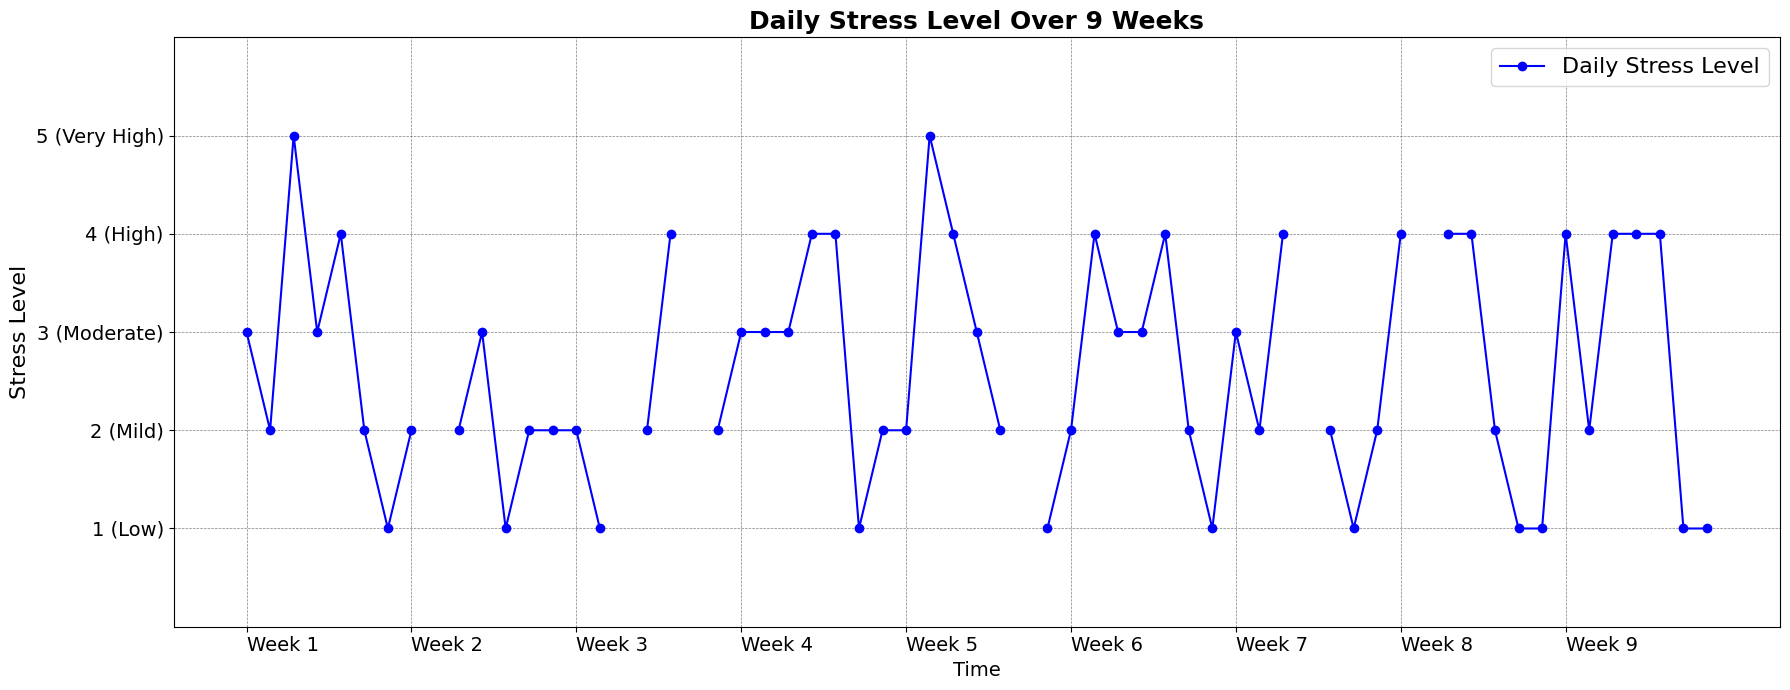

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. JSON data from your activity log
# I've noted that the provided log contains 9 weeks of data, not 10.
# The plot will reflect the 9 weeks present in the data.
json_data = """
{
  "Week 1": {
    "Monday": 3,
    "Tuesday": 2,
    "Wednesday": 5,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 2,
    "Sunday": 1
  },
  "Week 2": {
    "Monday": 2,
    "Tuesday": null,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 1,
    "Saturday": 2,
    "Sunday": 2
  },
  "Week 3": {
    "Monday": 2,
    "Tuesday": 1,
    "Wednesday": null,
    "Thursday": 2,
    "Friday": 4,
    "Saturday": null,
    "Sunday": 2
  },
  "Week 4": {
    "Monday": 3,
    "Tuesday": 3,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 4,
    "Saturday": 1,
    "Sunday": 2
  },
  "Week 5": {
    "Monday": 2,
    "Tuesday": 5,
    "Wednesday": 4,
    "Thursday": 3,
    "Friday": 2,
    "Saturday": null,
    "Sunday": 1
  },
  "Week 6": {
    "Monday": 2,
    "Tuesday": 4,
    "Wednesday": 3,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 2,
    "Sunday": 1
  },
  "Week 7": {
    "Monday": 3,
    "Tuesday": 2,
    "Wednesday": 4,
    "Thursday": null,
    "Friday": 2,
    "Saturday": 1,
    "Sunday": 2
  },
  "Week 8": {
    "Monday": 4,
    "Tuesday": null,
    "Wednesday": 4,
    "Thursday": 4,
    "Friday": 2,
    "Saturday": 1,
    "Sunday": 1
  },
  "Week 9": {
    "Monday": 4,
    "Tuesday": 2,
    "Wednesday": 4,
    "Thursday": 4,
    "Friday": 4,
    "Saturday": 1,
    "Sunday": 1
  }
}
"""

# 2. Load and process the data
try:
    data = json.loads(json_data)
except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")
    exit()

stress_levels = []
day_labels = []
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Sort weeks numerically to ensure correct order
sorted_weeks = sorted(data.keys(), key=lambda w: int(w.split(' ')[1]))

for week_name in sorted_weeks:
    week_number = week_name.split(' ')[1]
    for day in days_of_week:
        # Get the stress value, default to None if day is missing
        stress_value = data[week_name].get(day, None)

        # Use np.nan for missing values so matplotlib creates a gap in the line
        stress_levels.append(stress_value if stress_value is not None else np.nan)

        # Create a label for each day (e.g., "W1-Mon")
        day_labels.append(f"W{week_number}\n{day[:3]}")

# 3. Create the plot
fig, ax = plt.subplots(figsize=(18, 7))

# Plot the data with markers to show individual days
ax.plot(stress_levels, marker='o', linestyle='-', color='b', label='Daily Stress Level')

# --- Customize Appearance ---

# Set Title and Labels
ax.set_title('Daily Stress Level Over 9 Weeks', fontsize=18, fontweight='bold')
ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Stress Level', fontsize=16)

# Set Y-axis ticks and labels for clarity
ax.set_ylim(0, 6)
y_ticks = [1, 2, 3, 4, 5]
y_tick_labels = ['1 (Low)', '2 (Mild)', '3 (Moderate)', '4 (High)', '5 (Very High)']
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels)

# Set X-axis ticks to show the start of each week
num_weeks = len(sorted_weeks)
x_tick_positions = [i * 7 for i in range(num_weeks)]
x_tick_labels = [f'Week {i+1}' for i in range(num_weeks)]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, ha='left') # Align labels to the start of the week

ax.tick_params(axis='both', which='major', labelsize=14)

# Add a grid for better readability
ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')

# Add a horizontal line for the average stress level
# We use np.nanmean to ignore the missing (nan) values in the calculation
average_stress = np.nanmean(stress_levels)
# ax.axhline(y=average_stress, color='r', linestyle='--', label=f'Average Stress ({average_stress:.2f})')

# Add a legend
ax.legend(fontsize=16)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()

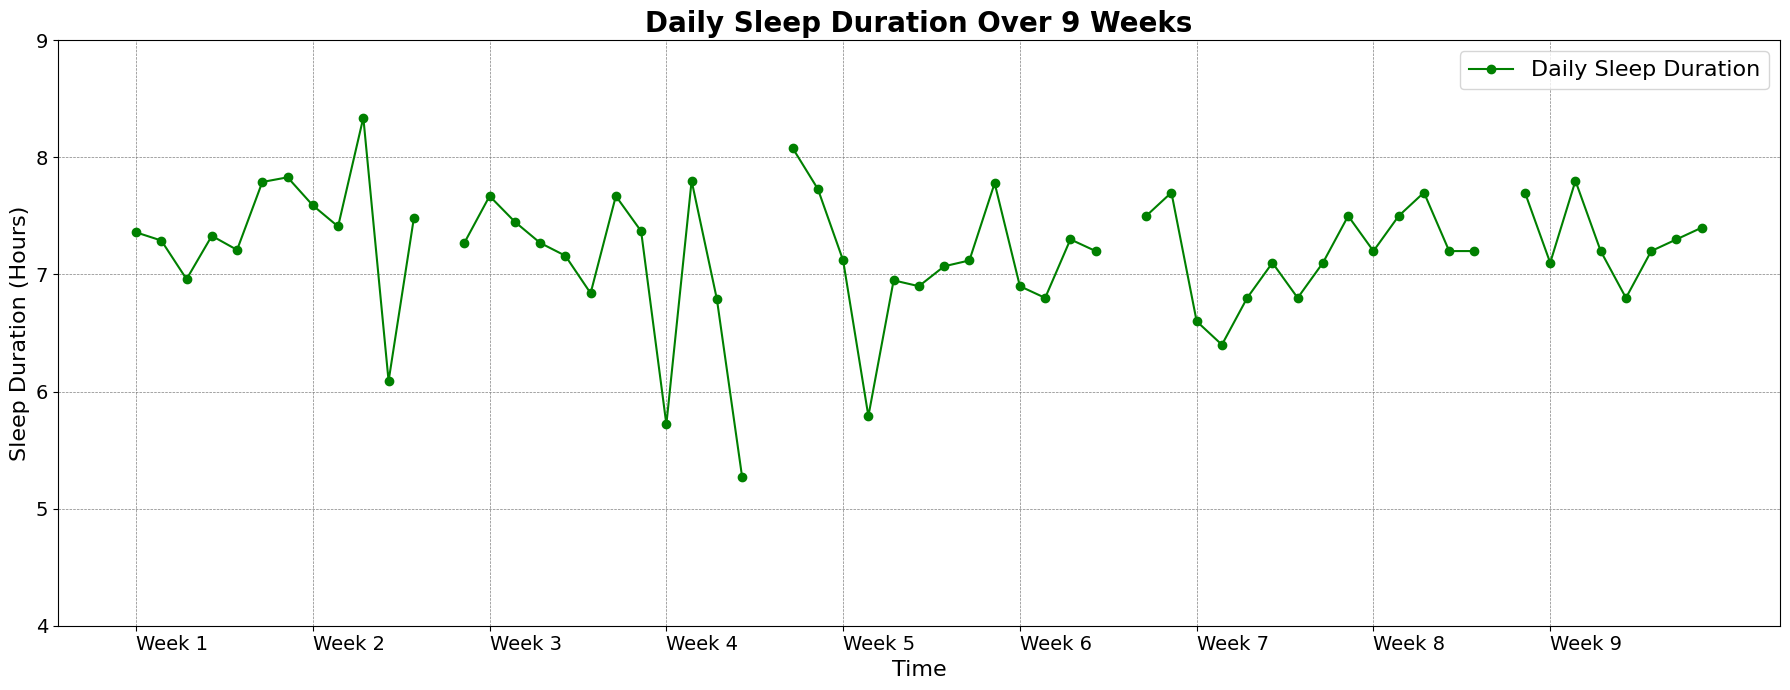

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. JSON data with extracted sleep hours
json_data = """
{
  "Week 1": { "Monday": 7.36, "Tuesday": 7.29, "Wednesday": 6.96, "Thursday": 7.33, "Friday": 7.21, "Saturday": 7.79, "Sunday": 7.83 },
  "Week 2": { "Monday": 7.59, "Tuesday": 7.41, "Wednesday": 8.34, "Thursday": 6.09, "Friday": 7.48, "Saturday": null, "Sunday": 7.27 },
  "Week 3": { "Monday": 7.67, "Tuesday": 7.45, "Wednesday": 7.27, "Thursday": 7.16, "Friday": 6.84, "Saturday": 7.67, "Sunday": 7.37 },
  "Week 4": { "Monday": 5.72, "Tuesday": 7.8, "Wednesday": 6.79, "Thursday": 5.27, "Friday": null, "Saturday": 8.08, "Sunday": 7.73 },
  "Week 5": { "Monday": 7.12, "Tuesday": 5.79, "Wednesday": 6.95, "Thursday": 6.9, "Friday": 7.07, "Saturday": 7.12, "Sunday": 7.78 },
  "Week 6": { "Monday": 6.9, "Tuesday": 6.8, "Wednesday": 7.3, "Thursday": 7.2, "Friday": null, "Saturday": 7.5, "Sunday": 7.7 },
  "Week 7": { "Monday": 6.6, "Tuesday": 6.4, "Wednesday": 6.8, "Thursday": 7.1, "Friday": 6.8, "Saturday": 7.1, "Sunday": 7.5 },
  "Week 8": { "Monday": 7.2, "Tuesday": 7.5, "Wednesday": 7.7, "Thursday": 7.2, "Friday": 7.2, "Saturday": null, "Sunday": 7.7 },
  "Week 9": { "Monday": 7.1, "Tuesday": 7.8, "Wednesday": 7.2, "Thursday": 6.8, "Friday": 7.2, "Saturday": 7.3, "Sunday": 7.4 }
}
"""

# 2. Load and process the data
try:
    data = json.loads(json_data)
except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")
    exit()

sleep_hours = []
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sorted_weeks = sorted(data.keys(), key=lambda w: int(w.split(' ')[1]))

for week_name in sorted_weeks:
    for day in days_of_week:
        sleep_value = data[week_name].get(day, None)
        # Use np.nan for missing values to create gaps in the line plot
        sleep_hours.append(sleep_value if sleep_value is not None else np.nan)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(18, 7))

# Plot the data with a different color and markers
ax.plot(sleep_hours, marker='o', linestyle='-', color='g', label='Daily Sleep Duration')

# --- Customize Appearance ---

# Set Title and Labels with desired font sizes
ax.set_title('Daily Sleep Duration Over 9 Weeks', fontsize=20, fontweight='bold')
ax.set_xlabel('Time', fontsize=16)
ax.set_ylabel('Sleep Duration (Hours)', fontsize=16)

# Set a reasonable Y-axis limit to emphasize variations
ax.set_ylim(4, 9)

# Set X-axis ticks to show the start of each week
num_weeks = len(sorted_weeks)
x_tick_positions = [i * 7 for i in range(num_weeks)]
x_tick_labels = [f'Week {i+1}' for i in range(num_weeks)]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, ha='left')

# Customize the size of the tick labels (e.g., 'Week 1', '5', '6')
ax.tick_params(axis='both', which='major', labelsize=14)

# Add a grid for better readability
ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')

# Add horizontal lines for a target sleep range (e.g., 7-9 hours)
# ax.axhspan(7, 9, color='green', alpha=0.1, label='Recommended Sleep (7-9 hrs)')

# Add a horizontal line for the average sleep duration
# np.nanmean ignores the missing (nan) values in the calculation
average_sleep = np.nanmean(sleep_hours)
# ax.axhline(y=average_sleep, color='orange', linestyle='--', label=f'Average Sleep ({average_sleep:.2f} hrs)')

# Add a legend with a custom font size
ax.legend(fontsize=16)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()

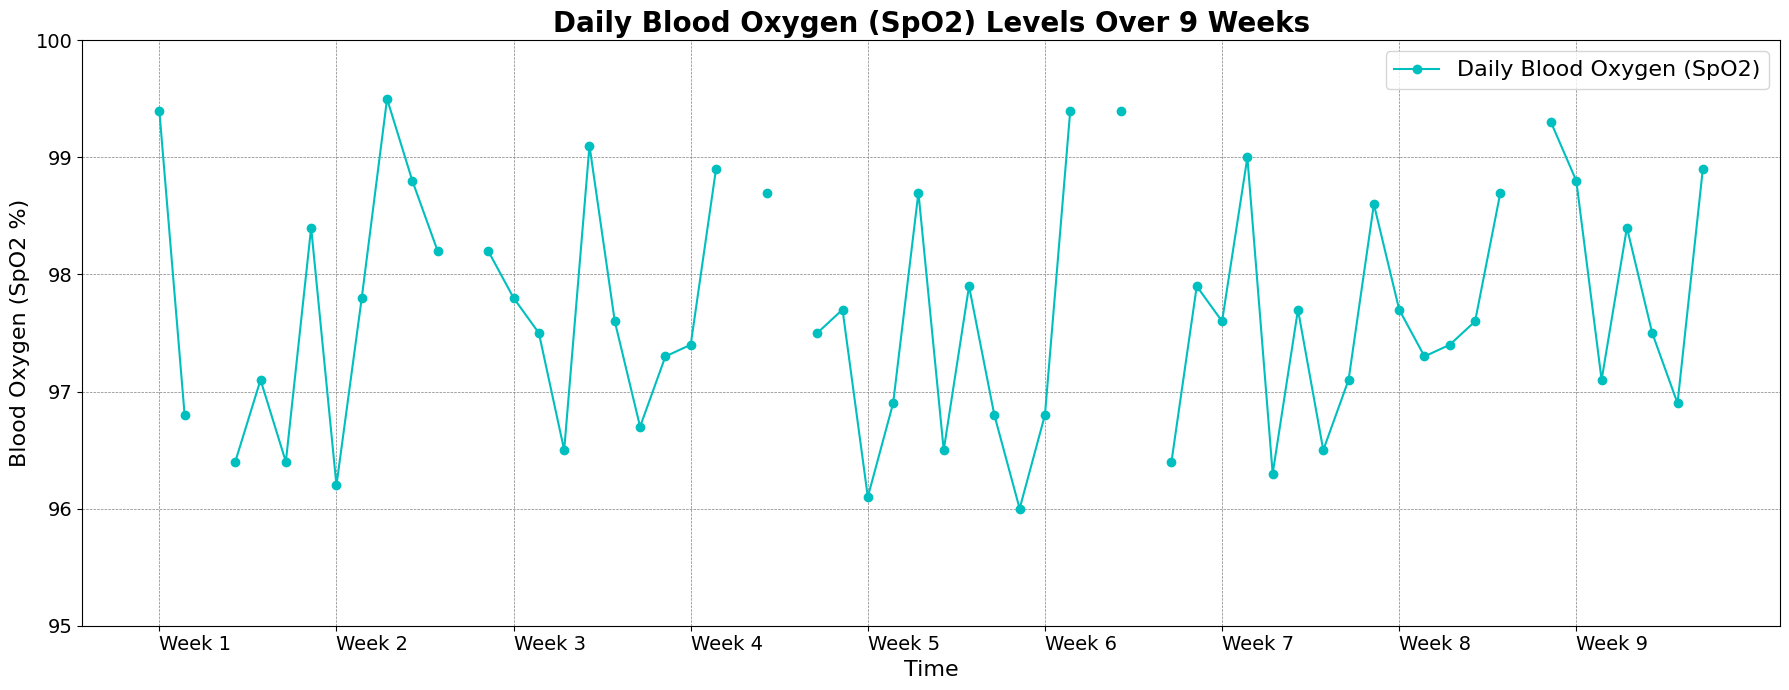

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. JSON data with extracted blood oxygen levels
json_data = """
{
  "Week 1": { "Monday": 99.4, "Tuesday": 96.8, "Wednesday": null, "Thursday": 96.4, "Friday": 97.1, "Saturday": 96.4, "Sunday": 98.4 },
  "Week 2": { "Monday": 96.2, "Tuesday": 97.8, "Wednesday": 99.5, "Thursday": 98.8, "Friday": 98.2, "Saturday": null, "Sunday": 98.2 },
  "Week 3": { "Monday": 97.8, "Tuesday": 97.5, "Wednesday": 96.5, "Thursday": 99.1, "Friday": 97.6, "Saturday": 96.7, "Sunday": 97.3 },
  "Week 4": { "Monday": 97.4, "Tuesday": 98.9, "Wednesday": null, "Thursday": 98.7, "Friday": null, "Saturday": 97.5, "Sunday": 97.7 },
  "Week 5": { "Monday": 96.1, "Tuesday": 96.9, "Wednesday": 98.7, "Thursday": 96.5, "Friday": 97.9, "Saturday": 96.8, "Sunday": 96.0 },
  "Week 6": { "Monday": 96.8, "Tuesday": 99.4, "Wednesday": null, "Thursday": 99.4, "Friday": null, "Saturday": 96.4, "Sunday": 97.9 },
  "Week 7": { "Monday": 97.6, "Tuesday": 99.0, "Wednesday": 96.3, "Thursday": 97.7, "Friday": 96.5, "Saturday": 97.1, "Sunday": 98.6 },
  "Week 8": { "Monday": 97.7, "Tuesday": 97.3, "Wednesday": 97.4, "Thursday": 97.6, "Friday": 98.7, "Saturday": null, "Sunday": 99.3 },
  "Week 9": { "Monday": 98.8, "Tuesday": 97.1, "Wednesday": 98.4, "Thursday": 97.5, "Friday": 96.9, "Saturday": 98.9, "Sunday": null }
}
"""

# 2. Load and process the data
try:
    data = json.loads(json_data)
except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")
    exit()

blood_oxygen_levels = []
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sorted_weeks = sorted(data.keys(), key=lambda w: int(w.split(' ')[1]))

for week_name in sorted_weeks:
    for day in days_of_week:
        spo2_value = data[week_name].get(day, None)
        # Use np.nan for missing values to create gaps in the line plot
        blood_oxygen_levels.append(spo2_value if spo2_value is not None else np.nan)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(18, 7))

# Plot the data with a different color and markers
ax.plot(blood_oxygen_levels, marker='o', linestyle='-', color='c', label='Daily Blood Oxygen (SpO2)')

# --- Customize Appearance ---

# Set Title and Labels with desired font sizes
ax.set_title('Daily Blood Oxygen (SpO2) Levels Over 9 Weeks', fontsize=20, fontweight='bold')
ax.set_xlabel('Time', fontsize=16)
ax.set_ylabel('Blood Oxygen (SpO2 %)', fontsize=16)

# Set a narrow Y-axis limit to highlight variations, as SpO2 values are typically in a small range
ax.set_ylim(95, 100)

# Set X-axis ticks to show the start of each week
num_weeks = len(sorted_weeks)
x_tick_positions = [i * 7 for i in range(num_weeks)]
x_tick_labels = [f'Week {i+1}' for i in range(num_weeks)]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, ha='left')

# Customize the size of the tick labels (e.g., 'Week 1', '96', '97')
ax.tick_params(axis='both', which='major', labelsize=14)

# Add a grid for better readability
ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')

# Add a legend with a custom font size
ax.legend(fontsize=16)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()